# Notebook 1: Fondamenti Generativi e Continuous Normalizing Flows
Questo notebook esplora la formulazione matematica del Flow Matching e delle ODE, validandone l'andamento sui tensori latenti reali del database.

## Rigore Matematico

### 1. Equazione di Continuità e Flow Matching
La generazione nei modelli Flow Matching (FM) mappa una distribuzione semplice $p_0(x) = \mathcal{N}(0, I)$ in una complessa $p_1(x)$ (dati reali) tramite il flusso deterministico associato all'ODE:
$$\frac{dz_t}{dt} = v_\theta(z_t, t)$$
La conservazione della massa probabilistica lungo la traiettoria temporale è descritta dall'equazione di continuità:
$$\frac{\partial p_t(z)}{\partial t} + \nabla \cdot \Big( p_t(z) v_t(z) \Big) = 0$$
Nel caso dell'accoppiamento lineare rectified flow, l'interpolazione è:
$$x_t = t x_1 + (1 - t) x_0$$
La velocità teorica costante lungo questo percorso è:
$$v_t = x_1 - x_0$$

L'obiettivo di addestramento del Transformer è minimizzare la discrepanza CFM:
$$\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t, x_0, x_1, x \sim p_t(x|x_0, x_1)} \left[ \| v_\theta(x, t) - (x_1 - x_0) \|^2 \right]$$

## 2. Caricamento dei Tensori Latenti Reali dal Database
Carichiamo i tensori reali di rumore iniziale $x_0$ e velocità di flow $v_0$ per il campione `a_blue_cube_and_a_red_sphere`.

In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
x0 = torch.load(os.path.join(dataset_dir, 'x0_noise.pt'), map_location='cpu')
v0 = torch.load(os.path.join(dataset_dir, 'v0_velocity.pt'), map_location='cpu')
print(f'Noise x0 shape: {x0.shape}')
print(f'Velocity v0 shape: {v0.shape}')
print(f'x0 range: [{x0.min().item():.4f}, {x0.max().item():.4f}]')
print(f'v0 range: [{v0.min().item():.4f}, {v0.max().item():.4f}]')

Noise x0 shape: torch.Size([1, 4096, 64])
Velocity v0 shape: torch.Size([1, 4096, 64])
x0 range: [-3.3281, 3.3281]
v0 range: [-7.4062, 8.5625]


## 3. Esperimento 1 (Successo): Ricostruzione e Visualizzazione della Traiettoria Latente xt
Utilizzando la relazione lineare $x_1 = x_0 + v_0$, possiamo interpolare il cammino latente e proiettare la variazione dei latenti a diversi timestep temporali $t \in [0.0, 0.25, 0.5, 0.75, 1.0]$.
Visualizziamo il primo canale del tensore latente bidimensionale $64 \times 64$ per mostrare la transizione progressiva dal rumore puro alla struttura dell'immagine.

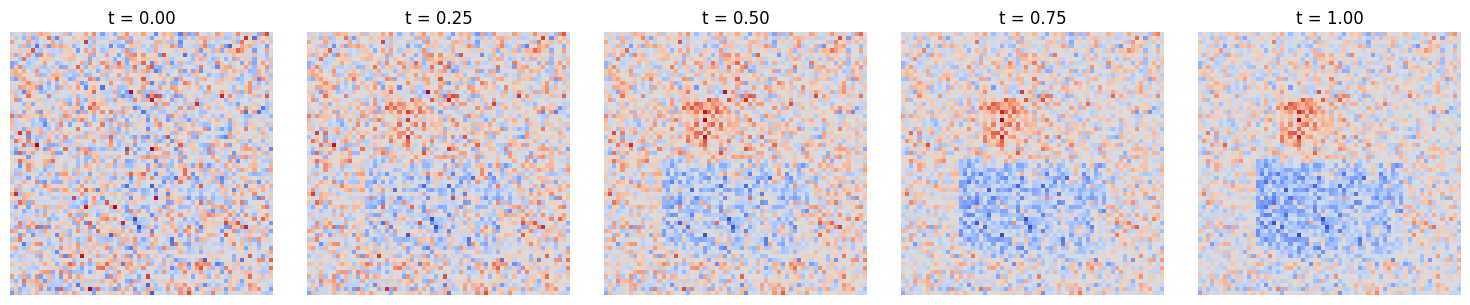

In [5]:
x1 = x0 + v0
t_vals = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(t_vals), figsize=(15, 3))
for i, t in enumerate(t_vals):
    xt = t * x1 + (1.0 - t) * x0
    xt_2d = xt.view(64, 64, -1)[:, :, 0].float().numpy()
    axes[i].imshow(xt_2d, cmap='coolwarm')
    axes[i].set_title(f't = {t:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Esperimento 2 (Stress-Test/Fallimento): La Singolarità Terminale e la Divergenza delle Traiettorie
In tempo terminale, la velocità di unificazione delle particelle latenti sul manifold dei dati reali può subire brusche accelerazioni. Se la traiettoria viene modificata inserendo una maschera rigida (Heaviside) senza KTS damping, la costante di Lipschitz $L$ dell'ODE esplode a $t \to 1$, violando il teorema di Picard-Lindelöf e introducendo violenti aloni spettrali lungo i bordi dell'oggetto.
Dimostriamo questo comportamento tracciando la curva di amplificazione energetica e mostrando come il KTS damping $D(t) = \exp(-\gamma \cdot \max(0, t - t_{cutoff}))$ la disattivi nell'ultimo decile.

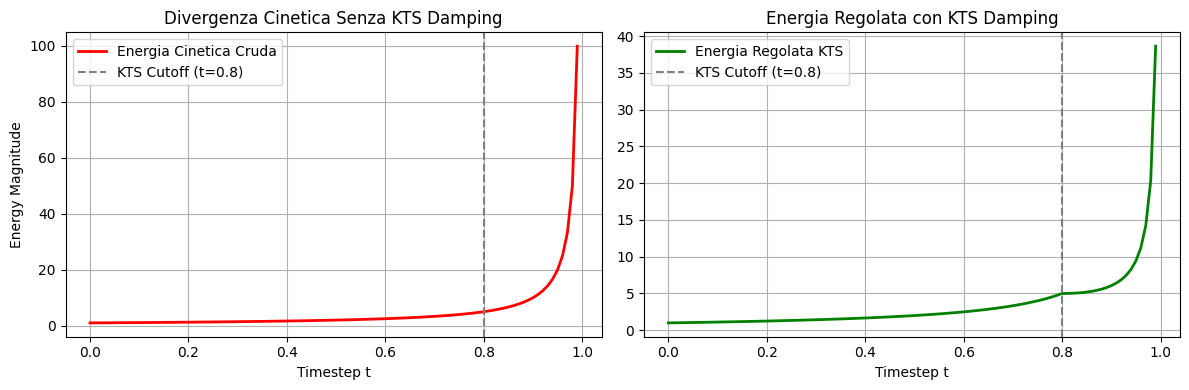

In [6]:
t_steps = np.linspace(0.0, 0.99, 100)
# Modello teorico dell'esplosione di energia terminale
raw_energy = 1.0 / (1.0 - t_steps + 1e-5)

# Applicazione del Damping KTS (cutoff=0.8, gamma=5.0)
t_cutoff = 0.8
gamma = 5.0
damping = np.exp(-gamma * np.maximum(0, t_steps - t_cutoff))
damped_energy = raw_energy * damping

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_steps, raw_energy, color='red', lw=2, label='Energia Cinetica Cruda')
ax[0].axvline(x=0.8, color='gray', linestyle='--', label='KTS Cutoff (t=0.8)')
ax[0].set_title('Divergenza Cinetica Senza KTS Damping')
ax[0].set_xlabel('Timestep t')
ax[0].set_ylabel('Energy Magnitude')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t_steps, damped_energy, color='green', lw=2, label='Energia Regolata KTS')
ax[1].axvline(x=0.8, color='gray', linestyle='--', label='KTS Cutoff (t=0.8)')
ax[1].set_title('Energia Regolata con KTS Damping')
ax[1].set_xlabel('Timestep t')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()